<a href="https://colab.research.google.com/github/noxidda/Nifty-Time-Series/blob/main/FinalNifty_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using columns -> Date: Date, Price: Adj Close
Dataset size: 1500

ADF Statistic: 0.3246336691844895
p-value: 0.9784468622228031

TensorFlow GPU: []
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0903
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0139
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0083
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0060
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0055
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0050
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0047
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0046
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0050
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0041
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0044
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0043
Epoch 13/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - lo

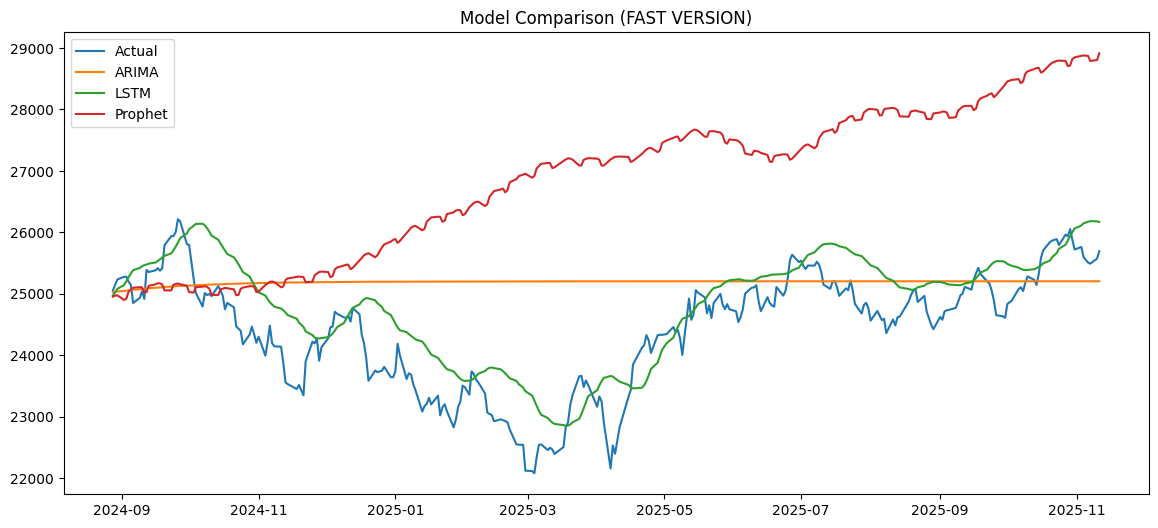

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

#optional imports
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    HAS_TF = False
    _TF_IMPORT_ERROR = e

try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception as e:
    HAS_PROPHET = False
    _PROPHET_IMPORT_ERROR = e


#load datasets
file_path = "/content/NIFTY_50.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

df_raw = pd.read_csv(file_path)


#auto detecting the columns
def find_column(cols, keywords):
    for key in keywords:
        for col in cols:
            if key.lower() in col.lower():
                return col
    return None

date_col = find_column(df_raw.columns, ["date", "time"])
price_col = find_column(df_raw.columns, ["close", "ltp", "price"])

if date_col is None or price_col is None:
    raise Exception("Could not detect Date or Price column")

print(f"Using columns -> Date: {date_col}, Price: {price_col}")


#data preprocessing
df = df_raw[[date_col, price_col]].copy()

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

df = df.dropna().sort_values(date_col)
df.rename(columns={price_col: "y"}, inplace=True)

df.set_index(date_col, inplace=True)

df = df.iloc[-1500:]

print("Dataset size:", len(df))


#train test split
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]


#adf test
result = adfuller(train["y"])
print("\nADF Statistic:", result[0])
print("p-value:", result[1])


#arima
model = ARIMA(train["y"], order=(2,1,2))
model_fit = model.fit()

arima_preds = model_fit.forecast(steps=len(test))
arima_preds = np.array(arima_preds)


#lstm
window = 60
lstm_preds = None

if HAS_TF:
    print("\nTensorFlow GPU:", tf.config.list_physical_devices('GPU'))

    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train[["y"]])
    scaled_full = scaler.transform(df[["y"]])

    def create_dataset(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i-window:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = create_dataset(scaled_train, window)

    X_test = []
    for i in range(train_size, len(df)):
        X_test.append(scaled_full[i-window:i])

    X_test = np.array(X_test)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window,1)),  # smaller = faster
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)

    lstm_preds = model.predict(X_test)
    lstm_preds = scaler.inverse_transform(lstm_preds).flatten()

else:
    print("Skipping LSTM:", _TF_IMPORT_ERROR)

#prophet
prophet_preds = None

if HAS_PROPHET:
    prophet_df = df.reset_index()
    prophet_df.columns = ["ds", "y"]

    prophet_train = prophet_df[:train_size]
    prophet_test = prophet_df[train_size:]

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True
    )

    model.fit(prophet_train)

    future = model.make_future_dataframe(periods=len(prophet_test))
    forecast = model.predict(future)

    prophet_preds = forecast["yhat"][-len(prophet_test):].values

else:
    print("Skipping Prophet:", _PROPHET_IMPORT_ERROR)


#metrics
def evaluate(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    r2 = r2_score(true, pred)
    return rmse, mae, mape, r2

y_true = test["y"].values

print("\n========== RESULTS ==========")

rmse, mae, mape, r2 = evaluate(y_true, arima_preds)
print(f"ARIMA   -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%, R2:{r2:.3f}")

if lstm_preds is not None:
    lstm_preds = lstm_preds[-len(test):]
    rmse, mae, mape, r2 = evaluate(y_true, lstm_preds)
    print(f"LSTM    -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%, R2:{r2:.3f}")

if prophet_preds is not None:
    rmse, mae, mape, r2 = evaluate(y_true, prophet_preds)
    print(f"Prophet -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%, R2:{r2:.3f}")

#plotting
plt.figure(figsize=(14,6))

plt.plot(test.index, y_true, label="Actual")
plt.plot(test.index, arima_preds, label="ARIMA")

if lstm_preds is not None:
    plt.plot(test.index, lstm_preds, label="LSTM")

if prophet_preds is not None:
    plt.plot(test.index, prophet_preds, label="Prophet")

plt.legend()
plt.title("Model Comparison (FAST VERSION)")
plt.show()